# 03 - So sánh mô hình, Late Fusion và tầng quyết định DSS

Protocol:

1. Dùng nhãn informative chính thức, join theo `(tweet_id, image_id)`.
2. Fit sáu model trên train.
3. Chọn họ model rồi tune siêu tham số trên dev leakage-safe.
4. Chọn trọng số fusion và threshold trên dev.
5. Báo cáo một lần trên test leakage-safe.
6. Text/image/fusion dùng cùng ground truth chung.
7. Luôn đối chiếu dummy baseline; không diễn giải F2 riêng lẻ.
8. Robust mask và bootstrap chỉ là hậu kiểm với cấu hình đã khóa, không tune lại.
9. CLIP là frozen feature extractor; không fine-tune CLIP.

In [1]:
import json, os, sys
sys.path.insert(0, os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from src.config import FIGURES_DIR, MODELS_DIR, REPORTS_DIR
from src.dashboard_data import load_dashboard_data

METRICS = os.path.join(REPORTS_DIR, "metrics")
with open(os.path.join(MODELS_DIR, "fusion_config.json"), encoding="utf-8") as f:
    fusion_config = json.load(f)
with open(os.path.join(METRICS, "data_quality_summary.json"), encoding="utf-8") as f:
    quality = json.load(f)
print("Evaluation rows:", fusion_config["evaluation_rows"])
print("Old derived-label mismatches:",
      quality["protocol"]["old_derived_informative_mismatches"])
fusion_config

Evaluation rows: {'validation': 2189, 'test': 2169}
Old derived-label mismatches: 2649


{'informative': {'text_weight': 0.7000000000000001,
  'image_weight': 0.29999999999999993,
  'threshold': 0.38000000000000006},
 'category': {'text_weight': 0.55, 'image_weight': 0.44999999999999996},
 'manual_review': {'conflict_threshold': 0.5399999999999999,
  'max_review_rate_on_dev': 0.25},
 'selection_split': 'leakage-safe dev',
 'evaluation_split': 'leakage-safe test',
 'evaluation_rows': {'validation': 2189, 'test': 2169},
 'target': 'official multimodal label'}

## 1. Sáu classifier trên dev

In [2]:
files = {
    "Text - informative": "text_informative_validation.csv",
    "Text - humanitarian": "text_humanitarian_validation.csv",
    "Image - informative": "image_informative_validation.csv",
    "Image - humanitarian": "image_humanitarian_validation.csv",
}
tables = {}
for title, filename in files.items():
    table = pd.read_csv(os.path.join(METRICS, filename))
    tables[title] = table
    print("\n", title)
    display(table)


 Text - informative


,Model,Accuracy,Precision,Recall,F1,F2
0,Logistic Regression,0.7085,0.7816,0.7368,0.7585,0.7453
1,Decision Tree,0.6044,0.7546,0.5382,0.6283,0.5710
2,Naive Bayes,0.7177,0.7265,0.8750,0.7939,0.8406
3,k-NN,0.4523,0.7193,0.1941,0.3057,0.2273
4,SVM (Linear),0.7204,0.7234,0.8904,0.7983,0.8511
5,Random Forest,0.7195,0.7457,0.8324,0.7867,0.8135



 Text - humanitarian


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Logistic Regression,0.4641,0.3145,0.4095,0.3297,0.4875
1,Decision Tree,0.2810,0.2118,0.2346,0.1302,0.1747
2,Naive Bayes,0.5263,0.2677,0.2429,0.2446,0.4982
3,k-NN,0.4079,0.3940,0.1449,0.1195,0.2871
4,SVM (Linear),0.5112,0.3019,0.2697,0.2787,0.4856
5,Random Forest,0.4947,0.2921,0.2571,0.2626,0.4734



 Image - informative


,Model,Accuracy,Precision,Recall,F1,F2
0,Logistic Regression,0.7579,0.8529,0.7375,0.7910,0.7580
1,Decision Tree,0.6807,0.7487,0.7316,0.7401,0.7350
2,Naive Bayes,0.7177,0.8681,0.6434,0.7390,0.6785
3,k-NN,0.7542,0.7915,0.8206,0.8058,0.8146
4,SVM (Linear),0.7593,0.8078,0.8037,0.8058,0.8045
5,Random Forest,0.7478,0.7949,0.8007,0.7978,0.7996



 Image - humanitarian


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Logistic Regression,0.5354,0.3603,0.4768,0.3637,0.5653
1,Decision Tree,0.4079,0.2288,0.2406,0.2323,0.4163
2,Naive Bayes,0.5477,0.3462,0.4028,0.3362,0.5590
3,k-NN,0.5943,0.4101,0.3530,0.3563,0.5851
4,SVM (Linear),0.6190,0.4889,0.3586,0.3631,0.5970
5,Random Forest,0.5706,0.5433,0.2760,0.2795,0.5262


**Lựa chọn trên dev.**

- Text informative: Linear SVM theo F2.
- Text humanitarian: Logistic Regression theo Macro-F1.
- Image informative: k-NN theo F2.
- Image humanitarian: Logistic Regression theo Macro-F1.

k-NN rất yếu trên TF-IDF thưa nhưng cạnh tranh trên embedding CLIP; đây là ví
dụ cùng thuật toán có hành vi khác khi biểu diễn đặc trưng thay đổi.

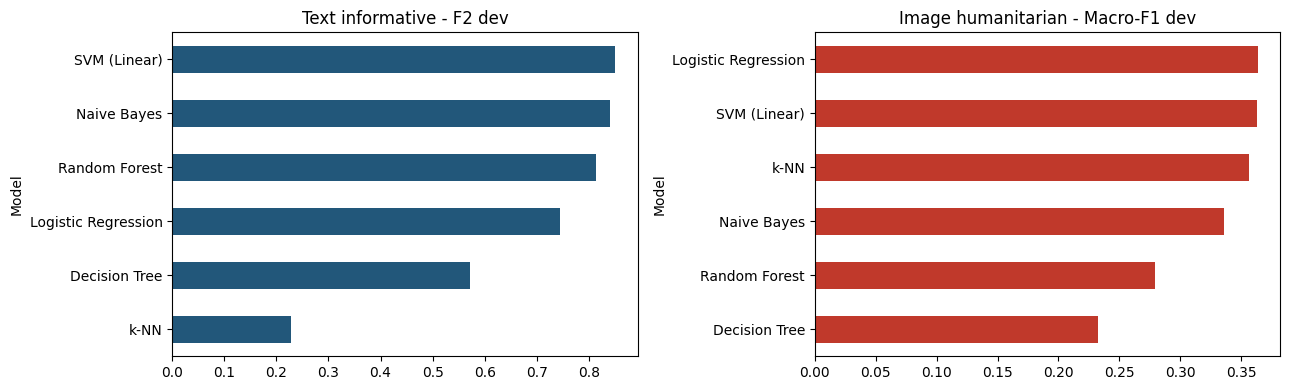

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
tables["Text - informative"].set_index("Model")["F2"].sort_values().plot.barh(
    ax=axes[0], color="#22577a"
)
axes[0].set_title("Text informative - F2 dev")
tables["Image - humanitarian"].set_index("Model")["Macro F1"].sort_values().plot.barh(
    ax=axes[1], color="#c0392b"
)
axes[1].set_title("Image humanitarian - Macro-F1 dev")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "model_validation_comparison.png"), bbox_inches="tight")
plt.show()

## 2. Tuning classifier trên dev

In [4]:
tuning_files = {
    "Text - informative": "text_informative_tuning.csv",
    "Text - humanitarian": "text_humanitarian_tuning.csv",
    "Image - informative": "image_informative_tuning.csv",
    "Image - humanitarian": "image_humanitarian_tuning.csv",
}
for title, filename in tuning_files.items():
    table = pd.read_csv(os.path.join(METRICS, filename))
    print("\n", title)
    display(table)
with open(os.path.join(METRICS, "tuned_model_summary.json"), encoding="utf-8") as f:
    tuned_summary = json.load(f)
tuned_summary


 Text - informative


,Parameters,Accuracy,Precision,Recall,F1,F2,Selected
0,"{""C"": 3.0}",0.7131,0.7135,0.8993,0.7957,0.8548,True
1,"{""C"": 1.0}",0.7204,0.7234,0.8904,0.7983,0.8511,False
2,"{""C"": 0.05}",0.7268,0.7346,0.8772,0.7996,0.8444,False
3,"{""C"": 0.3}",0.7204,0.7275,0.8794,0.7963,0.8442,False
4,"{""C"": 0.1}",0.7218,0.7322,0.8706,0.7954,0.8389,False



 Text - humanitarian


,Parameters,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Selected
0,"{""C"": 3.0}",0.4641,0.3136,0.3990,0.3297,0.4853,False
1,"{""C"": 1.0}",0.4641,0.3145,0.4095,0.3297,0.4875,True
2,"{""C"": 10.0}",0.4509,0.3112,0.3795,0.3275,0.4691,False
3,"{""C"": 0.3}",0.4646,0.3125,0.4177,0.3246,0.4911,False
4,"{""C"": 0.1}",0.4523,0.2994,0.4085,0.3076,0.4805,False
5,"{""C"": 0.05}",0.4354,0.2864,0.3854,0.2881,0.4662,False



 Image - informative


,Parameters,Accuracy,Precision,Recall,F1,F2,Selected
0,"{""n_neighbors"": 41, ""weights"": ""distance""}",0.7565,0.7890,0.8301,0.8090,0.8216,True
1,"{""n_neighbors"": 41, ""weights"": ""uniform""}",0.7556,0.7887,0.8287,0.8082,0.8204,False
2,"{""n_neighbors"": 25, ""weights"": ""uniform""}",0.7524,0.7864,0.8257,0.8056,0.8176,False
3,"{""n_neighbors"": 25, ""weights"": ""distance""}",0.7506,0.7854,0.8235,0.8040,0.8156,False
4,"{""n_neighbors"": 15, ""weights"": ""uniform""}",0.7542,0.7915,0.8206,0.8058,0.8146,False
5,"{""n_neighbors"": 15, ""weights"": ""distance""}",0.7538,0.7909,0.8206,0.8055,0.8145,False
6,"{""n_neighbors"": 9, ""weights"": ""uniform""}",0.7478,0.7849,0.8184,0.8013,0.8115,False
7,"{""n_neighbors"": 9, ""weights"": ""distance""}",0.7483,0.7863,0.8169,0.8013,0.8106,False
8,"{""n_neighbors"": 5, ""weights"": ""uniform""}",0.7455,0.7874,0.8088,0.7980,0.8044,False
9,"{""n_neighbors"": 5, ""weights"": ""distance""}",0.7446,0.7875,0.8066,0.7969,0.8027,False



 Image - humanitarian


,Parameters,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Selected
0,"{""C"": 1.0}",0.5354,0.3603,0.4768,0.3637,0.5653,True
1,"{""C"": 0.3}",0.5327,0.3598,0.4715,0.3587,0.5650,False
2,"{""C"": 3.0}",0.5349,0.3544,0.4444,0.3583,0.5636,False
3,"{""C"": 0.1}",0.5244,0.3546,0.4509,0.3471,0.5610,False
4,"{""C"": 10.0}",0.5148,0.3404,0.4232,0.3428,0.5463,False
5,"{""C"": 0.05}",0.5158,0.3500,0.4428,0.3397,0.5534,False


{'protocol': {'family_selection': 'six-model comparison on canonical dev',
  'hyperparameter_selection': 'canonical dev only',
  'final_evaluation': 'canonical test once after selection',
  'multiclass_tie_tolerance': 0.001,
  'clip': 'frozen feature extractor; no CLIP fine-tuning'},
 'evaluation_rows': {'train': 13608, 'val': 2189, 'test': 2169},
 'tasks': {'text_informative': {'selected_parameters': {'C': 3.0},
   'selection_metric': 'F2',
   'dev_metrics': {'Accuracy': 0.713111,
    'Precision': 0.713536,
    'Recall': 0.899265,
    'F1': 0.795706,
    'F2': 0.854767},
   'test_metrics': {'Accuracy': 0.705394,
    'Precision': 0.708912,
    'Recall': 0.900073,
    'F1': 0.793137,
    'F2': 0.854016}},
  'text_humanitarian': {'selected_parameters': {'C': 1.0},
   'selection_metric': 'Macro F1',
   'dev_metrics': {'Accuracy': 0.464139,
    'Macro Precision': 0.314513,
    'Macro Recall': 0.409502,
    'Macro F1': 0.329705,
    'Weighted F1': 0.487451},
   'test_metrics': {'Accuracy': 

**Kết quả tuning.**

- Text informative: Linear SVM chọn `C=3`, F2 dev tăng từ 0,8511 lên 0,8548.
- Text humanitarian: Logistic Regression giữ `C=1`. `C=3` chỉ nhỉnh
  Macro-F1 dưới 0,001 nhưng Weighted-F1 thấp hơn, nên quy tắc hòa chọn cấu hình
  bảo thủ.
- Image informative: k-NN chọn `k=41`, `weights=distance`, F2 dev tăng từ
  0,8146 lên 0,8216.
- Image humanitarian: Logistic Regression giữ `C=1`.
- Đây là tuning classifier cổ điển; trọng số CLIP không thay đổi.

## 3. Dummy baseline và kết quả cuối trên test leakage-safe

Dummy informative baselines


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,F2,MCC,Average Precision
0,Prior / majority,0.6275,0.5,0.6275,1.0,0.7711,0.8939,0.0,0.6275
1,Always informative,0.6275,0.5,0.6275,1.0,0.7711,0.8939,0.0,0.6275
2,Always not informative,0.3725,0.5,0.0000,0.0,0.0000,0.0000,0.0,0.6275


Dummy humanitarian baseline


,Model,Predicted Class,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,MCC
0,Train majority,not_humanitarian,0.3785,0.125,0.0686,0.2079,0.0


Final systems


,Model,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1,F2,MCC,Average Precision
0,Text-only,0.38,0.6823,0.5792,0.6675,0.9838,0.7954,0.8987,0.2904,0.7968
1,Image-only,0.20,0.6773,0.5759,0.6662,0.9735,0.7910,0.8913,0.2660,0.8999
2,Late Fusion,0.38,0.6948,0.5944,0.6755,0.9882,0.8025,0.9045,0.3325,0.8913


,Model,Accuracy,Macro F1,Weighted F1
0,Text-only,0.4481,0.3260,0.4693
1,Image-only,0.5440,0.3646,0.5695
2,Late Fusion,0.5569,0.4005,0.5776


,Unnamed: 0,Test
0,Accuracy,0.5579
1,Balanced Accuracy,0.5938
2,Precision,0.7532
3,Recall,0.3295
4,F1,0.4585
5,F2,0.3713
6,MCC,0.2150
7,Average Precision,0.7092
8,Review Rate,0.2485


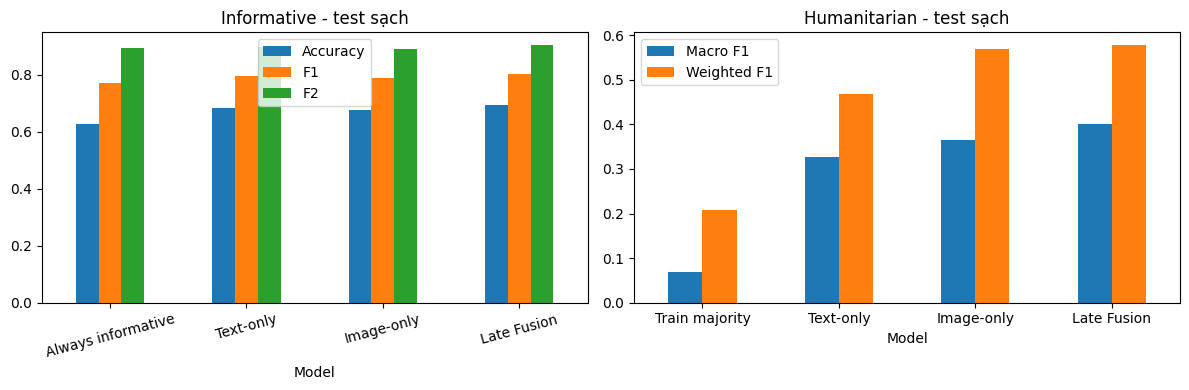

In [5]:
binary = pd.read_csv(os.path.join(METRICS, "fusion_informative_test.csv"))
category = pd.read_csv(os.path.join(METRICS, "fusion_humanitarian_test.csv"))
review = pd.read_csv(os.path.join(METRICS, "manual_review_test.csv"))
dummy_binary = pd.read_csv(
    os.path.join(METRICS, "baseline_informative_test.csv")
)
dummy_category = pd.read_csv(
    os.path.join(METRICS, "baseline_humanitarian_test.csv")
)
print("Dummy informative baselines")
display(dummy_binary)
print("Dummy humanitarian baseline")
display(dummy_category)
print("Final systems")
display(binary)
display(category)
display(review)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
informative_plot = pd.concat([
    dummy_binary[dummy_binary["Model"] == "Always informative"][
        ["Model", "Accuracy", "F1", "F2"]
    ],
    binary[["Model", "Accuracy", "F1", "F2"]],
])
informative_plot.set_index("Model").plot.bar(ax=axes[0], rot=15)
axes[0].set_title("Informative - test sạch")
category_plot = pd.concat([
    dummy_category[["Model", "Macro F1", "Weighted F1"]],
    category[["Model", "Macro F1", "Weighted F1"]],
])
category_plot.set_index("Model").plot.bar(
    ax=axes[1], rot=0
)
axes[1].set_title("Humanitarian - test sạch")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fusion_test_comparison.png"), bbox_inches="tight")
plt.show()

**Diễn giải có đối chứng.**

- Dummy luôn dự báo `informative` đã đạt F2 = 0,8939 vì positive rate là
  62,75%. Late Fusion đạt 0,9045, chỉ hơn 0,0106 F2; không được dùng F2 riêng
  làm bằng chứng hệ thống mạnh.
- Giá trị của informative fusion rõ hơn ở Accuracy 0,6948 so với 0,6275, F1
  0,8025 so với 0,7711, Balanced Accuracy 0,5944 và MCC 0,3325.
- Với humanitarian, majority baseline Macro-F1 chỉ 0,0686 trong khi fusion đạt
  0,4005. Đây là bằng chứng mạnh hơn cho giá trị phân loại tám lớp.
- Ảnh tạo mức cải thiện rõ hơn ở nhiệm vụ tám lớp; text đóng vai trò lớn hơn
  trong informative với trọng số dev-tuned 0,70/0,30.

## 4. Phân tích theo lớp và lỗi

,precision,recall,f1-score,support
injured_or_dead_people,0.2202,0.6316,0.3265,38.0
missing_or_found_people,0.0435,0.2000,0.0714,5.0
rescue_volunteering_or_donation_effort,0.5262,0.5468,0.5363,331.0
infrastructure_and_utility_damage,0.4925,0.5305,0.5108,311.0
affected_individuals,0.2124,0.5000,0.2982,82.0
vehicle_damage,0.1385,0.5000,0.2169,18.0
other_relevant_information,0.6588,0.4938,0.5645,563.0
not_humanitarian,0.7507,0.6200,0.6791,821.0


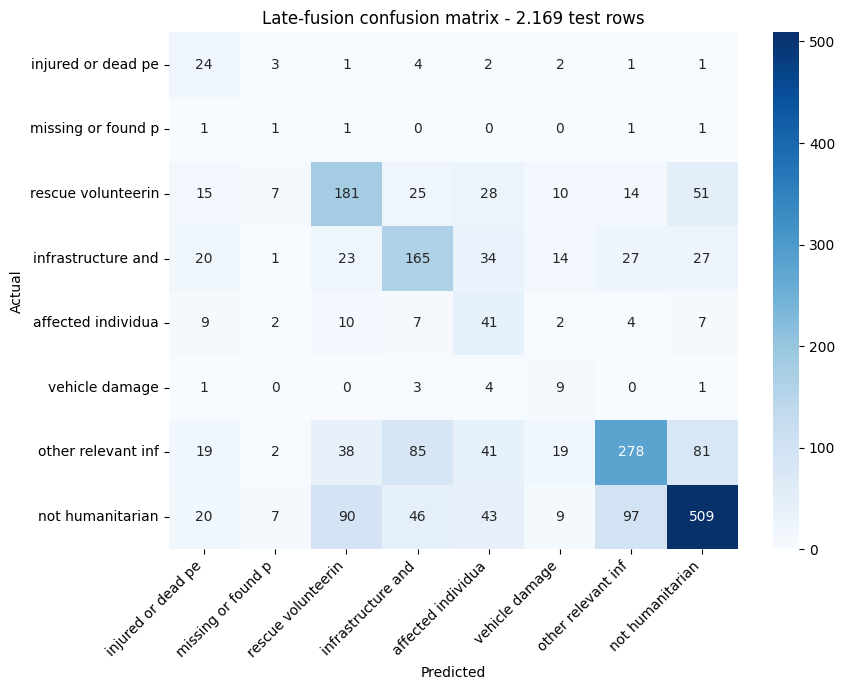

In [6]:
class_report = pd.read_csv(
    os.path.join(METRICS, "fusion_humanitarian_classification_report.csv"),
    index_col=0,
)
display(class_report.iloc[:8])

predictions = load_dashboard_data()
safe = predictions[predictions["evaluation_eligible"].astype(bool)].copy()
labels = list(class_report.index[:8])
cm = confusion_matrix(
    safe["true_category"], safe["fused_category"], labels=labels
)
short = [label.replace("_", " ")[:18] for label in labels]
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=short, yticklabels=short)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Late-fusion confusion matrix - 2.169 test rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "confusion_humanitarian.png"), bbox_inches="tight")
plt.show()

**Giới hạn quan trọng.** `missing_or_found_people` chỉ có 5 mẫu test sạch
và F1 = 0,0714; `vehicle_damage` có 18 mẫu và F1 = 0,2169. Macro-F1 phản ánh
đúng điểm yếu này. Hệ thống chưa đủ bằng chứng để tự động hóa quyết định sinh
tử cho lớp hiếm; các case đó cần người xác minh.

## 5. Robustness: near-duplicate, bootstrap, event và class

,Task,Metric,Canonical,Robust,Delta
0,Informative Fusion,Accuracy,0.694790,0.689961,-0.004830
1,Informative Fusion,Balanced Accuracy,0.594369,0.596492,0.002122
2,Informative Fusion,Precision,0.675540,0.669359,-0.006181
3,Informative Fusion,Recall,0.988244,0.987292,-0.000952
4,Informative Fusion,F1,0.802506,0.797818,-0.004688
5,Informative Fusion,F2,0.904506,0.901639,-0.002866
6,Informative Fusion,MCC,0.332469,0.333963,0.001494
7,Informative Fusion,Average Precision,0.891343,0.887594,-0.003749
8,Humanitarian Fusion,Accuracy,0.556939,0.557579,0.000640
9,Humanitarian Fusion,Macro F1,0.400466,0.390816,-0.009650


,Task,Metric,Estimate,CI Low,CI High,CI Width,Bootstrap SE,Resamples,Method
0,Informative Fusion,Accuracy,0.689961,0.678150,0.701772,0.023622,0.006018,2000,stratified by informative target
1,Informative Fusion,F1,0.797818,0.791229,0.804264,0.013035,0.003332,2000,stratified by informative target
2,Informative Fusion,F2,0.901639,0.896029,0.906977,0.010948,0.002816,2000,stratified by informative target
3,Informative Fusion,MCC,0.333963,0.296992,0.367620,0.070628,0.018247,2000,stratified by informative target
4,Informative Fusion vs Dummy,F2 Gain,0.011006,0.005395,0.016343,0.010948,0.002816,2000,"paired, stratified by informative target"
5,Humanitarian Fusion,Accuracy,0.557579,0.535913,0.578740,0.042827,0.010677,2000,stratified by humanitarian target
6,Humanitarian Fusion,Macro F1,0.390816,0.363599,0.420805,0.057205,0.014823,2000,stratified by humanitarian target
7,Humanitarian Fusion,Weighted F1,0.578878,0.558016,0.599286,0.041270,0.010452,2000,stratified by humanitarian target
8,Humanitarian Fusion vs Dummy,Macro F1 Gain,0.320830,0.293613,0.350819,0.057205,0.014823,2000,"paired, stratified by humanitarian target"
9,Manual Review,Precision,0.754032,0.721211,0.790395,0.069183,0.017502,2000,stratified by disagreement target


,Event,Rows,Informative F2,Humanitarian Macro F1 (present classes),Review F1
0,hurricane_harvey,523,0.915376,0.461527,0.451306
1,hurricane_irma,523,0.894849,0.388111,0.433790
2,hurricane_maria,471,0.887516,0.369928,0.457300
3,california_wildfires,184,0.924309,0.358422,0.385093
4,mexico_earthquake,151,0.913201,0.361815,0.530303
5,srilanka_floods,119,0.820513,0.460333,0.451613
6,iraq_iran_earthquake,61,0.917031,0.345755,0.656250


,Class,Canonical F1,Robust F1,F1 Delta,Robust Support,Stability Flag
0,injured_or_dead_people,0.326531,0.297521,-0.029010,28,low support
1,missing_or_found_people,0.071429,0.076923,0.005495,4,low support
2,rescue_volunteering_or_donation_effort,0.536296,0.539683,0.003386,304,stable
3,infrastructure_and_utility_damage,0.510836,0.506757,-0.004079,285,stable
4,affected_individuals,0.298182,0.298039,-0.000143,77,stable
5,vehicle_damage,0.216867,0.166667,-0.050201,15,low support
6,other_relevant_information,0.564467,0.561822,-0.002645,529,stable
7,not_humanitarian,0.679119,0.679115,-0.000005,790,stable


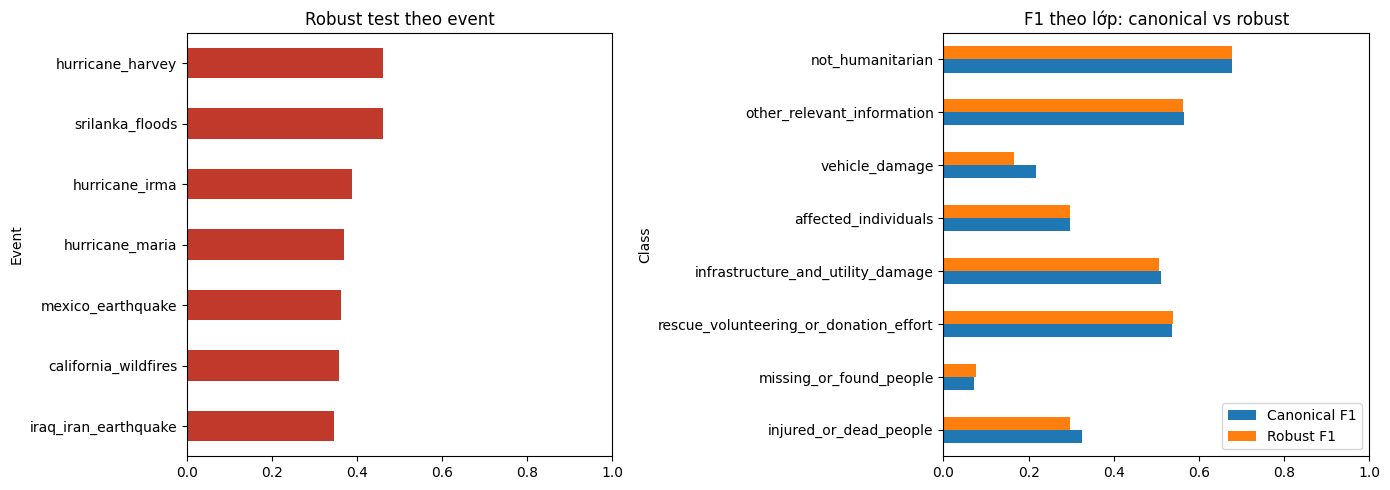

In [7]:
robust_comparison = pd.read_csv(
    os.path.join(METRICS, "robustness_metric_comparison.csv")
)
bootstrap = pd.read_csv(
    os.path.join(METRICS, "robust_bootstrap_intervals.csv")
)
event_stability = pd.read_csv(
    os.path.join(METRICS, "robust_event_stability.csv")
)
class_stability = pd.read_csv(
    os.path.join(METRICS, "robust_class_stability.csv")
)

core = robust_comparison[
    robust_comparison["Task"].isin(
        ["Informative Fusion", "Humanitarian Fusion", "Manual Review"]
    )
]
display(core)
display(bootstrap)
display(event_stability[[
    "Event", "Rows", "Informative F2",
    "Humanitarian Macro F1 (present classes)", "Review F1"
]])
display(class_stability[[
    "Class", "Canonical F1", "Robust F1", "F1 Delta",
    "Robust Support", "Stability Flag"
]])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
event_stability.sort_values(
    "Humanitarian Macro F1 (present classes)"
).plot.barh(
    x="Event",
    y="Humanitarian Macro F1 (present classes)",
    legend=False,
    color="#c0392b",
    ax=axes[0],
)
axes[0].set_xlim(0, 1)
axes[0].set_title("Robust test theo event")
class_stability.plot.barh(
    x="Class",
    y=["Canonical F1", "Robust F1"],
    ax=axes[1],
)
axes[1].set_xlim(0, 1)
axes[1].set_title("F1 theo lớp: canonical vs robust")
plt.tight_layout()
plt.show()

**Diễn giải hậu kiểm.**

- Sau khi loại thêm 137 test rows near-duplicate đã xác minh, informative F2
  giảm từ 0,9045 xuống 0,9016; humanitarian Macro-F1 giảm từ 0,4005 xuống
  0,3908. Cấu hình không được tune lại.
- Trên 2.000 bootstrap phân tầng, F2 robust có CI 95% [0,8960; 0,9070].
  Paired F2 gain so với always-informative là 0,0110, CI [0,0054; 0,0163]:
  khác 0 theo giả định row-bootstrap nhưng độ lớn thực tiễn nhỏ.
- Humanitarian Macro-F1 robust có CI [0,3636; 0,4208], gain so với majority
  baseline có CI [0,2936; 0,3508], là bằng chứng mạnh hơn.
- Theo event, informative F2 thấp nhất ở Sri Lanka floods (0,8205);
  humanitarian Macro-F1 thấp nhất ở Iraq-Iran earthquake (0,3458, 61 rows).
  Đây là tín hiệu domain shift, không phải ước lượng deployment chắc chắn.
- Ba lớp injured/dead, missing/found và vehicle damage vẫn có support dưới 30.
  Không có lớp support đủ lớn nào dịch F1 quá 0,05 giữa hai mask.

## 6. Manual Review

In [8]:
print("Conflict threshold:", fusion_config["manual_review"]["conflict_threshold"])
print("Dev capacity:", fusion_config["manual_review"]["max_review_rate_on_dev"])
display(review)

Conflict threshold: 0.5399999999999999
Dev capacity: 0.25


,Unnamed: 0,Test
0,Accuracy,0.5579
1,Balanced Accuracy,0.5938
2,Precision,0.7532
3,Recall,0.3295
4,F1,0.4585
5,F2,0.3713
6,MCC,0.2150
7,Average Precision,0.7092
8,Review Rate,0.2485


Ngưỡng conflict được chọn trên dev với capacity 25%. Trên test, review
rate là 24,85%, precision 0,7532 và recall 0,3295. Đây là trade-off vận hành:
hàng đợi tập trung vào xung đột mạnh, không cố thu hồi toàn bộ xung đột.

## 7. Kiểm tra logic Risk Score và routing

In [9]:
scenarios = pd.read_csv(os.path.join(METRICS, "dss_scenarios.csv"))
sensitivity = pd.read_csv(
    os.path.join(METRICS, "dss_threshold_sensitivity.csv")
)
display(scenarios[[
    "scenario", "risk_score", "base_priority", "priority",
    "assigned_team", "manual_review"
]])
display(sensitivity)

,scenario,risk_score,base_priority,priority,assigned_team,manual_review
0,critical_injury,98.8,High,High,Emergency Team,False
1,infrastructure_damage,77.8,High,High,Infrastructure Team,False
2,ordinary_post,4.0,Low,Low,No Action,False
3,critical_conflict,98.8,High,High,Supervisor + Emergency Team,True


,policy,low_max,medium_max,low_cases,medium_cases,high_cases
0,sensitive,29,59,651,1186,332
1,current,39,69,769,1351,49
2,strict,49,79,1212,955,2


Risk Score không có nhãn ground truth trong CrisisMMD, nên trọng số và
ngưỡng Priority là **policy minh bạch**, không được tuyên bố là tối ưu thống kê.
Scenario test xác nhận: post thường có score thấp; case sinh tử cao; conflict
High được review song song với Emergency Team và không bị hạ xuống Medium.
Bảng sensitivity cho thấy số case High thay đổi mạnh khi policy đổi, do đó
ngưỡng phải được trung tâm vận hành phê duyệt.

## 8. Tóm tắt bằng chứng thực nghiệm

- Mô hình: có so sánh đủ sáu thuật toán ở bốn nhánh/task.
- Tuning: có lưới siêu tham số, quy tắc hòa và test chỉ dùng sau khi khóa.
- Evaluation: tách train/dev/test và loại duplicate hash xuyên split.
- Fusion: trọng số và threshold chọn trên dev, test chỉ dùng báo cáo.
- Baseline: có dummy đối chứng; F2 informative không được diễn giải độc lập.
- Robustness: có mask review thủ công, sensitivity, bootstrap, event/class stability.
- Error analysis: có confusion matrix và per-class metrics.
- DSS: có scenario test, routing đủ tám lớp, sensitivity và human-in-the-loop.